In [176]:
import numpy as np
import pandas as pd

# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi


In [177]:

# =========================
# Two-body decay generator
# =========================

def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df



In [178]:

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df   

In [179]:
# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937
}


# =========================
# Generate datasets
# =========================

N = 10000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))

# Combine everything
df = pd.concat(df_list, ignore_index=True)

print(df.head())

   process       E1       px1       py1       pz1       E2       px2  \
0  Jpsi→pp  1.54845  0.568731 -1.060105  0.265660  1.54845 -0.568731   
1  Jpsi→pp  1.54845  0.144922  0.812041 -0.915118  1.54845 -0.144922   
2  Jpsi→pp  1.54845  0.648767 -1.023813 -0.220820  1.54845 -0.648767   
3  Jpsi→pp  1.54845  0.127533  0.077010 -1.222971  1.54845 -0.127533   
4  Jpsi→pp  1.54845 -0.738120  0.802228  0.573988  1.54845  0.738120   

        py2       pz2  m_inv  
0  1.060105 -0.265660    NaN  
1 -0.812041  0.915118    NaN  
2  1.023813  0.220820    NaN  
3 -0.077010  1.222971    NaN  
4 -0.802228 -0.573988    NaN  


In [180]:
m2 = (
    (df["E1"] + df["E2"])**2
    - (df["px1"] + df["px2"])**2
    - (df["py1"] + df["py2"])**2
    - (df["pz1"] + df["pz2"])**2
)

df["m_inv"] = np.sqrt(np.maximum(m2, 0))

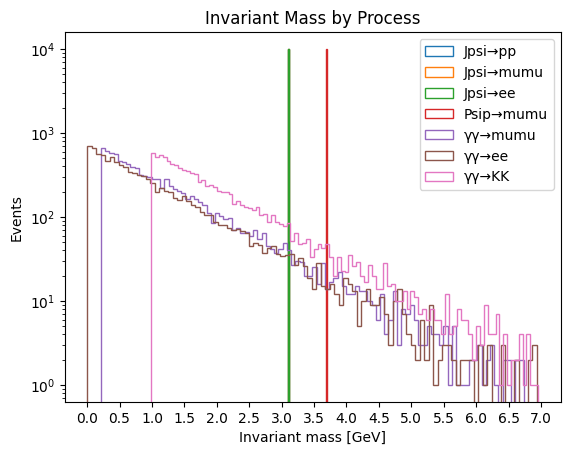

In [181]:
for proc in df["process"].unique():
    subset = df[df["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()